<a href="https://colab.research.google.com/github/SuwonCHOO/CSW_protein260918/blob/main/AI%EA%B8%B0%EB%B0%98%EC%8B%A0%EC%95%BD%EA%B0%9C%EB%B0%9C_Ligand_activity_prediction_using_fingerprint_%26_random_forest_2026_0923%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest를 이용한 ligand activity 예측
----

본 강의에서는 기본적인 Random Forest algorithm을 이용하여 다양한 유기분자의 단백질과의 상호작용의 크기를 예측하는 모델을 만들어 본다.





RDKit은 화학정보학 계산을 위해서 널리 사용되는 파이썬 라이브러리입니다.

RDKit에 관한 강의는 따로 제약바이오협회 사이트에 제가 진행한 동영상 강의가 업로드 되어 있습니다.

 https://laidd.org/

# RDKit 설치
----


In [ ]:
!pip install rdkit

In [ ]:
import rdkit

## RDKit version 확인
------


In [ ]:
rdkit.__version__

'2026.03.2'

In [ ]:
import rdkit.Chem

## 데이터 읽어들이기
----
이번 실습에서는 알려진 JAK2의 IC50 데이터를 사용해서 주어진 유기 분자의 결합친화도를 예측하는 모델을 학습시켜본다.

ChEMBL DB에서 JAK2의 IC50 데이터는 아래 링크에서 검색 및 다운로드 받을 수 있음.

https://www.ebi.ac.uk/chembl/web_components/explore/activities/STATE_ID:53884XhFBZyibRlOVCaWFA%3D%3D


pIC50
-------
IC50는 특정 억제 물질(약물 등)이 시험관 내에서 생물학적 과정이나 성분을 50% 억제하는 데 필요한 양을 나타내는 정량적 측정값임.


In [ ]:
import pandas as pd

pubchem = pd.read_csv("https://www.dropbox.com/scl/fi/jmczmk509z7e04115fcxa/jak2_data.csv?rlkey=r9e6a65hnh61z93zrysditkgx&dl=1")

In [ ]:
pubchem

,SMILES,pIC50
0,O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1cccs1,4.26
1,O=c1cc(-c2nc(-c3ccc(-c4cn(CCP(=O)(O)O)nn4)cc3)...,4.34
2,NC(=O)c1ccc2c(c1)nc(C1CCC(O)CC1)n2CCCO,4.53
3,NCCCn1c(C2CCNCC2)nc2cc(C(N)=O)ccc21,4.56
4,CNC(=S)Nc1cccc(-c2cnc3ccccc3n2)c1,4.59
...,...,...
1906,CC(=O)N1CCCCC(Nc2ncccc2-c2cnc3[nH]ccc3n2)C1,10.72
1907,CN1CCN(c2ncc(-c3cnc4[nH]ccc4n3)c(NC3CCCN(S(=O)...,10.76
1908,CC1CN(S(=O)(=O)CC2CCC(N(C)c3[nH]cnc4nccc3-4)CC...,10.78
1909,CS(=O)(=O)N1CCC(Nc2ncccc2-c2cnc3[nH]ccc3n2)C1,10.97


## 이번 실습에서는 1911개의 데이터를 사용할 예정임.
----

중복된 데이터가 있다면 제거하자.


In [ ]:
pip install tqdm

In [ ]:
from rdkit import Chem
from tqdm import tqdm

idx = 0
pic50_list = []
smi_list = []
mol_list = []
for pic50, smi in zip(tqdm(pubchem["pIC50"]), pubchem["SMILES"]):
  mol = rdkit.Chem.MolFromSmiles(smi) # 분자를 Mol-type으로 변환
  if mol is None: # Errorneous SMILES
    print(f"{smi} is errorneous.")
    continue
  can_smi = rdkit.Chem.MolToSmiles(mol) # canonical SMILES로 변환
  if can_smi not in smi_list: # canonical SMILES가 smi_list 안에 없다면.. (중복제거)
    smi_list.append(can_smi)
    pic50_list.append(pic50)
    mol_list.append(mol)
    idx += 1
  else:
    print(f"{can_smi} has a duplicate")
print(f"There are {idx} non-redundant molecules.")

 32%|███▏      | 617/1911 [00:00<00:00, 3112.66it/s]

O=C1NC(=O)C(c2c[nH]c3ccccc23)=C1Nc1cccc(OC2CCN(c3ccnc(F)c3)C2)c1 has a duplicate
CC(=O)NC1CCc2ccc(Oc3cnc4[nH]cc(C(=O)NC(C)C)c4n3)cc21 has a duplicate
NC(=O)c1cnc2[nH]ccc2c1NC1CCCN(Cc2ccccc2)C1 has a duplicate
N#CC1CC(NC(C2CC2)C(F)(F)F)CCC1n1cc(C(N)=O)c(Nc2ccc(C(F)(F)F)cc2)n1 has a duplicate
CC1CC(C)N1C1CCC(n2cc(C(N)=O)c(Nc3ccc(C(F)(F)F)cc3)n2)C(C#N)C1 has a duplicate
CC1CC(C)N1C1CCC(n2cc(C(N)=O)c(Nc3ccc(C(F)(F)F)cc3)n2)C(C#N)C1 has a duplicate
O=c1[nH]c2cnc(-n3cnc4ccccc43)nc2n1C1CCOc2c(F)cccc21 has a duplicate
N#CC1CCCC(O)C1n1cc(C(N)=O)c(Nc2ccccc2)n1 has a duplicate
CC(NC(=O)c1cnn2ccc(N3CCCC3c3cc(F)cn(C)c3=O)nc12)C1CC1 has a duplicate
O=c1[nH]c2cnc(-n3cnc4ccccc43)nc2n1C1CCOc2c(F)cccc21 has a duplicate
N#CC1CCC2(CC1n1cc(C(N)=O)c(Nc3ccccc3)n1)OCCO2 has a duplicate
CC(NC1CCC(n2cc(C(N)=O)c(Nc3ccc(C(F)(F)F)nc3)n2)C(C#N)C1)C1CC1 has a duplicate
CC1(O)CCCC1Nc1c(C(N)=O)cnn2cccc12 has a duplicate
N#CC1CC(NC(C2CC2)C(F)(F)F)CCC1n1cc(C(N)=O)c(Nc2ccc(C(F)(F)F)cc2)n1 has a duplicate
CC(NC1CCC(n2cc(C

 65%|██████▌   | 1248/1911 [00:00<00:00, 3137.97it/s]

CS(=O)(=O)N1CCCC(NC(=O)Nc2cnc3[nH]ccc3n2)C1 has a duplicate
N#CC1CCC2(CC1n1cc(C(N)=O)c(Nc3ccccc3)n1)OCCO2 has a duplicate
CC(NC1CCC(n2cc(C(N)=O)c(Nc3ccc(S(=O)(=O)C(F)(F)F)cc3)n2)C(C#N)C1)C1CC1 has a duplicate
CC(NC(=O)c1c[nH]c2ncc(C3CC3)nc12)C(C)(C)O has a duplicate
CC1(C)C(O)CCC1Nc1c(C(N)=O)cnn2cccc12 has a duplicate
N#CC1CC(N2CCC2)CCC1n1cc(C(N)=O)c(Nc2ccc(Cl)cc2)n1 has a duplicate
CC1(C)CN(C2CCC(n3cc(C(N)=O)c(Nc4ccc(C(F)(F)F)cc4)n3)C(C#N)C2)C1 has a duplicate
N#CC1CC(NC(C2CC2)C2CC2)CCC1n1cc(C(N)=O)c(Nc2ccc(S(=O)(=O)C(F)(F)F)cc2)n1 has a duplicate
N#CC1CC(C(=O)NCC(F)(F)F)CCC1n1cc(C(N)=O)c(Nc2ccc(Cl)cc2)n1 has a duplicate
N#CC1CC(N2CCC2)CCC1n1cc(C(N)=O)c(Nc2ccnc(F)c2)n1 has a duplicate
N#CC1CC(N2CC3(CCC3)C2)CCC1n1cc(C(N)=O)c(Nc2ccnc(F)c2)n1 has a duplicate
CC(C)(O)C1CN(C2CCC(n3cc(C(N)=O)c(Nc4ccc(Cl)cc4)n3)C(C#N)C2)C1 has a duplicate
N#CC1CC(NC2(C(F)(F)F)CC2)CCC1n1cc(C(N)=O)c(Nc2ccc(Cl)cc2)n1 has a duplicate
CC1(C)CCN1C1CCC(n2cc(C(N)=O)c(Nc3ccc(C(F)(F)F)cc3)n2)C(C#N)C1 has a duplicate
N

100%|██████████| 1911/1911 [00:00<00:00, 3070.52it/s]

N#CC1CC(NCC(F)F)CCC1n1cc(C(N)=O)c(Nc2ccc(S(=O)(=O)C(F)(F)F)cc2)n1 has a duplicate
CC1(O)CCC(n2cc(C(N)=O)c(Nc3ccc(C(C)(O)C(F)(F)F)cc3)n2)C(C#N)C1 has a duplicate
CC1(C)CN(C2CCC(n3cc(C(N)=O)c(Nc4ccc(C(O)C(F)(F)F)cc4)n3)C(C#N)C2)C1 has a duplicate
CC1(O)CCC(n2cc(C(N)=O)c(Nc3ccc(C(C)(O)C(F)(F)F)cc3)n2)C(C#N)C1 has a duplicate
N#CC1CC(N2CCC2)CCC1n1cc(C(N)=O)c(Nc2ccc(S(=O)(=O)C(F)(F)F)cc2)n1 has a duplicate
CC1(c2ccc(Nc3nn(C4CCC(O)CC4C#N)cc3C(N)=O)cc2)COC1 has a duplicate
CC(C)(c1ccc(Nc2nn(C3CCCCC3C#N)cc2C(N)=O)cc1F)C(O)C(F)(F)F has a duplicate
N#Cc1ccc(N2CCC(Nc3c(C(N)=O)cnc4[nH]ccc34)C(F)C2)nc1 has a duplicate
N#CC1CC(O)CCC1n1cc(C(N)=O)c(Nc2ccc(S(=O)(=O)C(F)(F)F)cc2)n1 has a duplicate
N#CC1CCCCC1n1cc(C(N)=O)c(Nc2ccc(C(O)C(F)F)nc2)n1 has a duplicate
N#CC1CC(NC2COC2)CCC1n1cc(C(N)=O)c(Nc2ccc(CC(F)(F)F)cc2)n1 has a duplicate
CC1(O)CN(C2CCC(n3cc(C(N)=O)c(Nc4ccc(C(F)(F)F)cc4)n3)C(C#N)C2)C1 has a duplicate
N#CC1CC(O)CCC1n1cc(C(N)=O)c(Nc2ccc(C(O)C(F)(F)F)cc2)n1 has a duplicate
N#Cc1ccc(Nc2nn(C3CCC(

# Converting a molecule into an extended circular fingerprint (ECFP)

----

분자를 n개의 0과 1의 비트 벡터(bit vector)로 전환한다.
주어진 유기 분자의 각 heavy atom을 중심으로 하여 반지름을 바꾸어 가며(radius=0, 1, 2) 분자의 조각(fragment)를 생성한다.
최대 radius = 1이면 지름이 2이기 때문에 ECFP2라고 부르고 radius = 2이면 지름이 4이기 때문에 ECFP4라고 부른다.

![ecfp](https://docs.chemaxon.com/display/docs/images/download/attachments/1806333/ecfp_generation.png)


Each fragment is assigned to a specific bit

![ecfp2](https://docs.chemaxon.com/display/docs/images/download/attachments/1806333/ecfp_folding.png)

(ref: https://pubs.acs.org/doi/10.1021/ci100050t)

일반적으로 1024개 혹은 2048개의 bit 사용한다.


아래는 older version의 RDKit code임.

In [ ]:
from rdkit.Chem import AllChem
mol = rdkit.Chem.MolFromSmiles(smi_list[0]) # SMILES -> Mol-type 변수로 읽어들인다.
vec = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits = 1024) # ECFP2를 이용. 1024개의 0/1로 표현하겠다.

[08:38:45] DEPRECATION WARNING: please use MorganGenerator


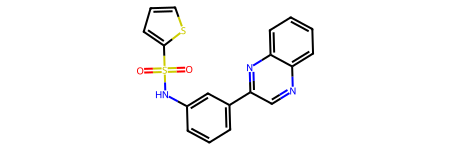

In [ ]:
mol

In [ ]:
smi_list[0]

'O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1cccs1'

In [ ]:
print(vec)

In [ ]:
print(vec.ToList())

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

# RDKit을 이용해서 분자들을 ECFP로 변환
----

In [ ]:
from tqdm import tqdm # progressive bar 표시를 위해서...
from rdkit.Chem import rdFingerprintGenerator

# Morgan Fingerprint generator
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024) # ECFP4 -> 1024 bit로 나타낸다.

X_ECFP = []
for mol in mol_list:
  fp = fpgen.GetFingerprint(mol) # fingerprint로 변환.
  fp_list = fp.ToList() # fingerprint를 0과 1의 리스트로 변환.
  X_ECFP.append(fp_list)

In [ ]:
len(X_ECFP)

1720

In [ ]:
print(X_ECFP[0])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
Y = pd.DataFrame(pic50_list) # 예측하고자하는 목표 물성: pIC50

In [ ]:
X_df = pd.DataFrame(X_ECFP, columns=[f"bit_{i}" for i in range(1024)])

In [ ]:
X_df

,bit_0,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,bit_9,...,bit_1014,bit_1015,bit_1016,bit_1017,bit_1018,bit_1019,bit_1020,bit_1021,bit_1022,bit_1023
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1715,0,1,0,0,1,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1716,0,0,0,0,1,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,0
1717,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,0
1718,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
Y

,0
0,4.26
1,4.34
2,4.53
3,4.56
4,4.59
...,...
1715,10.71
1716,10.72
1717,10.76
1718,10.78


# Spliting training and test set
----
Let's split the whole data into the training and test set.

![split_set](https://miro.medium.com/max/1400/1*-NC7sX7kzjJ_UKfUNYbh6Q.webp)

The ratio of training, validation, and test (holdout) data is a little bit arbitrary.

The most common ratios are 6:2:2, 8:1:1, and 7:1:2 etc.

## Scikit-learn 로드
----

In [ ]:
import sklearn
from sklearn.model_selection import train_test_split

## Train : Test = 8 : 2
----

전체 데이터를 8:2의 비율로 training / test set으로 나누자.

In [ ]:
train_X, test_X, train_y, test_y = train_test_split(X_df, Y, test_size = 0.2, shuffle=True)

In [ ]:
print(len(train_X))

1376


In [ ]:
print(len(test_X))

344


## Training set을 Training / Validation set으로 나눔.
----

Traing set의 크기를 확인해보자
----

In [ ]:
type(train_X)

pandas.core.frame.DataFrame

In [ ]:
len(train_X)

1376

In [ ]:
train_X

,bit_0,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,bit_9,...,bit_1014,bit_1015,bit_1016,bit_1017,bit_1018,bit_1019,bit_1020,bit_1021,bit_1022,bit_1023
1465,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1380,0,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
54,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
827,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
566,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1461,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
747,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1343,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
train_y

,0
1465,8.62
1380,8.30
54,5.00
827,7.29
566,6.85
...,...
333,6.30
1461,8.59
747,7.17
1343,8.22


# Random Forest 모델을 이용해서 pIC50 값을 예측하게 만들어보자!
----

자세한 설명은
Random Forest regressor:

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

Random Forest classifier:

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20240130162938/random.webp">



In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_regressor = RandomForestRegressor(random_state=57431) # blank 모델 선언(정의)

학습을 진행하자!


In [ ]:
%%time
rf_regressor.fit(train_X, train_y)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


CPU times: user 8.93 s, sys: 6.71 ms, total: 8.94 s
Wall time: 8.98 s


RandomForestRegressor(random_state=57431)

In [ ]:
test_X

,bit_0,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,bit_9,...,bit_1014,bit_1015,bit_1016,bit_1017,bit_1018,bit_1019,bit_1020,bit_1021,bit_1022,bit_1023
1252,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1516,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
202,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1165,0,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
191,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1464,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
793,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
599,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
107,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


학습된 모델을 예측해보자!


In [ ]:
pred_y = rf_regressor.predict(test_X)

In [ ]:
print(pred_y)

[ 7.5734      8.6995      7.1422      6.3234      6.2346      6.7189
  7.5517      7.455       7.6314      7.174375    5.2804      6.8557
  6.1596      5.0842      6.2083      9.8839      6.5006      8.48556012
  6.378       8.9006      8.7697      7.4262      7.462       6.8724
  8.4909      7.3874      7.947       6.7897      8.3338      7.6551
  7.6407      6.3133      7.08        7.3967      6.6334      7.3905
  7.5347      9.7422      6.2794      7.3086      8.3368      6.432
  6.5015      7.3038      7.4539      6.4964      8.262       6.614
  7.4997      7.6405      7.2418      7.5426      6.6294      7.5502
  9.9728     10.2298      7.201       6.99585     8.0105      7.5994
  7.3046      6.9732      7.4004      6.5227      7.9737      9.8891
  7.1283      7.165       8.2939      7.5181      7.1968      8.7281
  7.4261      7.9147      7.5295      8.9551      6.4777      7.7117
  6.8967      7.2727      6.6023      7.3624      8.8118      7.428
  7.2222      6.86515     7.6711 

# 예측성능 Test
----
test set의 성능을 확인하기 위한 함수.

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(test_y, pred_y)
print(f"평균 제곱 오차: {mse:.3f} (pIC50)")

평균 제곱 오차: 0.483 (pIC50)


## 예측 결과를 plot 해봅시다.
----

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

scatter plot으로 그려보자!


Text(0.5, 1.0, 'Exp. vs. Predictions')

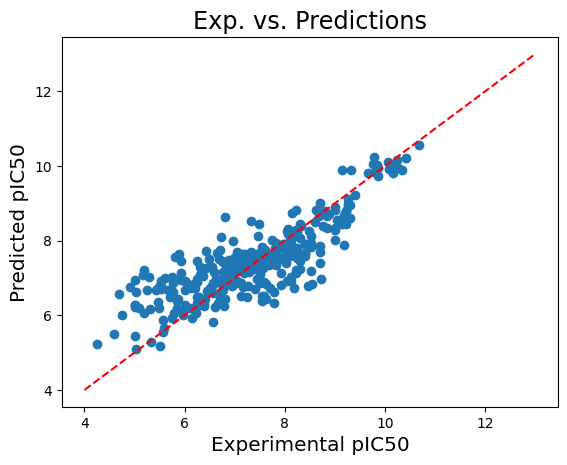

In [ ]:
plt.scatter(test_y, pred_y) # scatter plot 그림.

plt.plot(range(4, 14, 1), range(4, 14, 1),  'r--', ms=0.01,) # diagonal line (대각선)을 그려줌.

plt.xlabel("Experimental pIC50", fontsize='x-large')
plt.ylabel("Predicted pIC50", fontsize='x-large')
plt.title("Exp. vs. Predictions", fontsize='xx-large')

## Pearson correlation coefficient 를 계산
----


In [ ]:
test_y.iloc[:,0]

,0
1252,8.00
1516,8.89
202,5.93
1165,7.78
191,5.90
...,...
1464,8.62
793,7.24
599,6.91
107,5.51


In [ ]:
import numpy as np

np.corrcoef(test_y.iloc[:, 0], pred_y) # Calculate the Pearson's correlation coefficient.

array([[1.        , 0.83782078],
       [0.83782078, 1.        ]])

0.85~0.86 정도의 Pearson correlation coefficient를 가진다!

### Feature importance
--------


In [ ]:
feature_importance = []

for name, val in zip([f"bit_{i}" for i in range(1024)], rf_regressor.feature_importances_):
  feature_importance.append((name, val))

# sort by importance value.
feature_importance = sorted(feature_importance, key=lambda x: x[1], reverse=True)

for name, val in feature_importance[:20]:
  print(f"{name}: {val:.4f}")

bit_124: 0.2127
bit_926: 0.0269
bit_850: 0.0261
bit_732: 0.0229
bit_223: 0.0188
bit_773: 0.0142
bit_319: 0.0137
bit_565: 0.0127
bit_52: 0.0126
bit_370: 0.0100
bit_98: 0.0094
bit_136: 0.0094
bit_352: 0.0090
bit_456: 0.0083
bit_495: 0.0079
bit_33: 0.0072
bit_491: 0.0071
bit_703: 0.0068
bit_231: 0.0063
bit_639: 0.0060


### Visualize bit value
--------


In [ ]:
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

ao = AllChem.AdditionalOutput()
ao.CollectBitInfoMap()

molecules_with_bit_124 = []
for m in mol_list:
  fp = fpgen.GetFingerprint(m, additionalOutput=ao)
  bi = ao.GetBitInfoMap()
  if 124 in bi:
    print(bi[124])
    molecules_with_bit_124.append((m, bi))

((3, 1), (1, 1))
((1, 1),)
((1, 1),)
((23, 2),)
((1, 1),)
((1, 1),)
((1, 1),)
((9, 2),)
((1, 1),)
((9, 1),)
((1, 1),)
((1, 1),)
((1, 1),)
((1, 1),)
((1, 1),)
((9, 2),)
((15, 2),)
((15, 2),)
((15, 2),)
((7, 2),)
((16, 2),)
((19, 2),)
((18, 2),)
((16, 2),)
((18, 2),)
((19, 2),)
((18, 2),)
((18, 2),)
((23, 2),)
((18, 2),)
((17, 2),)
((19, 2),)
((14, 2),)
((1, 1), (11, 2))
((17, 2),)
((7, 2),)
((17, 2),)
((18, 2),)
((24, 2),)
((16, 2),)
((16, 2),)
((1, 1), (11, 2))
((20, 2),)
((6, 2),)
((1, 1), (18, 2))
((16, 2),)
((10, 2),)
((19, 2),)
((10, 2),)
((10, 2),)
((28, 2),)
((16, 2),)
((22, 2),)
((5, 2),)
((20, 2),)
((18, 2),)
((17, 2),)
((5, 2),)
((16, 2),)
((25, 2),)
((1, 1), (11, 2))
((7, 2),)
((6, 2),)
((7, 2),)
((11, 2),)
((5, 2),)
((17, 2),)
((16, 2),)
((16, 2),)
((18, 2),)
((26, 2),)
((10, 2),)
((10, 2),)
((15, 2),)
((14, 2),)
((20, 2),)
((16, 2),)
((15, 2),)
((9, 1), (27, 2))
((1, 1), (18, 2))
((14, 2),)
((6, 2),)
((9, 2),)
((6, 2),)
((11, 2),)
((8, 1), (19, 2))
((20, 2),)
((23, 2),)
((2

bit_124에 포함되어 있는 fragment의 정보를 도시화(depict) 해보자.

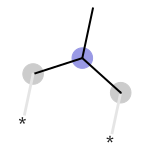

{5: ((5, 2), (35, 2)), 33: ((0, 0), (4, 0)), 102: ((26, 1),), 112: ((27, 1),), 114: ((16, 0),), 121: ((21, 1),), 124: ((3, 1), (1, 1)), 128: ((11, 0),), 173: ((32, 2),), 191: ((10, 1),), 203: ((24, 2),), 233: ((8, 2), (34, 2)), 262: ((16, 2),), 268: ((2, 1),), 281: ((3, 2), (1, 2)), 285: ((0, 1), (4, 1)), 305: ((27, 2), (22, 2)), 323: ((20, 1),), 356: ((7, 0), (10, 0), (12, 0), (15, 0), (20, 0), (21, 0), (23, 0), (26, 0), (30, 0)), 360: ((28, 0),), 378: ((13, 0), (32, 0)), 381: ((7, 2),), 388: ((15, 2),), 407: ((6, 1),), 410: ((20, 2),), 419: ((15, 1),), 428: ((13, 1),), 429: ((17, 1), (18, 1), (19, 1)), 438: ((6, 2),), 458: ((12, 2),), 491: ((11, 1),), 500: ((10, 2),), 511: ((14, 1),), 544: ((13, 2),), 558: ((12, 1),), 562: ((11, 2),), 580: ((31, 1),), 607: ((29, 2),), 630: ((31, 2),), 640: ((2, 2),), 656: ((31, 0),), 667: ((30, 2),), 674: ((27, 0),), 702: ((14, 2),), 726: ((8, 1), (9, 1), (24, 1), (25, 1), (33, 1), (34, 1)), 739: ((5, 1), (35, 1)), 784: ((30, 1),), 790: ((28, 1),), 8

In [ ]:
m, bi = molecules_with_bit_124[0]
mfp2_svg = Draw.DrawMorganBit(m, 124, bi, useSVG=True)
display(mfp2_svg)
print(m)
print(bi)

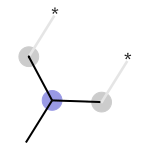

{4: ((3, 1),), 5: ((23, 2),), 11: ((1, 2),), 15: ((16, 2),), 33: ((0, 0),), 64: ((16, 1),), 90: ((7, 0),), 102: ((18, 1),), 112: ((19, 1),), 117: ((2, 2),), 124: ((1, 1),), 136: ((14, 1),), 198: ((5, 2),), 285: ((0, 1),), 290: ((9, 2),), 301: ((2, 1),), 305: ((19, 2),), 323: ((14, 2),), 352: ((13, 1),), 356: ((6, 0), (10, 0), (13, 0), (14, 0), (18, 0), (22, 0)), 360: ((20, 0),), 361: ((10, 1),), 378: ((9, 0), (11, 0)), 401: ((6, 2),), 407: ((5, 1),), 428: ((9, 1), (11, 1)), 446: ((3, 2),), 456: ((4, 1),), 471: ((13, 2),), 511: ((12, 1),), 585: ((7, 2),), 602: ((6, 1),), 674: ((19, 0),), 680: ((4, 2),), 710: ((17, 2),), 713: ((8, 1),), 723: ((22, 1),), 726: ((15, 1), (17, 1)), 736: ((15, 2),), 739: ((23, 1),), 743: ((12, 2),), 790: ((20, 1),), 806: ((7, 1),), 818: ((21, 2),), 834: ((8, 2),), 849: ((8, 0), (12, 0), (15, 0), (16, 0), (17, 0), (21, 0)), 867: ((11, 2),), 875: ((21, 1),), 888: ((10, 2),), 926: ((2, 0), (3, 0), (4, 0), (23, 0)), 935: ((5, 0),), 951: ((18, 2),), 981: ((22, 2),

In [ ]:
m, bi = molecules_with_bit_124[1]
mfp2_svg = Draw.DrawMorganBit(m, 124, bi, useSVG=True)
display(mfp2_svg)
print(m)
print(bi)

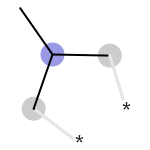

In [ ]:
m, bi = molecules_with_bit_124[2]
mfp2_svg = Draw.DrawMorganBit(m, 124, bi, useSVG=True)
display(mfp2_svg)

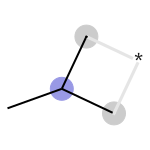

In [ ]:
m, bi = molecules_with_bit_124[4]
mfp2_svg = Draw.DrawMorganBit(m, 124, bi, useSVG=True)
display(mfp2_svg)

# Saving the trained model
------
pickle 모듈을 이용!

In [ ]:
import pickle

pickle.dump(rf_regressor, open("my_model.pkl", "wb"))

# Loading the saved model
----
torch.load를 이용!

In [ ]:
model2 = pickle.load(open("my_model.pkl", "rb"))

In [ ]:
print(model2)

RandomForestRegressor(random_state=57431)


In [ ]:
model2.predict(test_X)

array([ 7.9094    ,  8.6755    ,  6.40031   ,  7.4011    ,  6.084     ,
        7.2483    ,  7.7308    ,  7.3958    ,  7.6525    ,  7.3031    ,
        5.1289    ,  6.6004    ,  5.7129    ,  5.0469    ,  5.5266    ,
        9.3383    ,  7.1063    ,  8.29918   ,  7.3208    ,  8.9348    ,
        8.7473    ,  7.4763    ,  6.6745    ,  7.4331    ,  8.8251    ,
        7.641     ,  7.8761    ,  6.2096    ,  8.7688    ,  7.571     ,
        7.9037    ,  6.4447    ,  5.6542    ,  8.3187    ,  5.6012    ,
        7.3995    ,  7.5562    ,  9.8559    ,  5.9102    ,  6.9326    ,
        8.648     ,  6.5843    ,  6.0263    ,  6.7026    ,  7.54      ,
        6.6386    ,  8.3497    ,  6.1999    ,  6.9608    ,  7.7508    ,
        6.90635   ,  7.3916    ,  6.099     ,  7.1913    , 10.0501    ,
        9.827     ,  7.4661    ,  6.1252    ,  7.8803    ,  7.4979    ,
        7.3673    ,  7.5855    ,  7.79      ,  6.8396    ,  8.0551    ,
        9.8712    ,  7.1364    ,  7.123     ,  8.3082    ,  6.70

# Molecular Descriptor를 가지고 예측 모델을 만들어보자.
------


RDKit에서 계산할 수 있는 모든 분자 기술자(molecular descriptor)를 계산한 후, 이를 feature로 사용하는 모델을 만들어보자.


In [ ]:
import rdkit.Chem.Descriptors as Descriptors
import pandas as pd

desc_list = []

# Calculate all possible molecular descriptors for each molecule in mol_list
for mol in tqdm(mol_list):
    desc = Descriptors.CalcMolDescriptors(mol)
    desc_list.append(desc)

# Convert the list of descriptor dictionaries to a Pandas DataFrame
desc_df = pd.DataFrame(desc_list)

print(f"Calculated {len(desc_df.columns)} molecular descriptors for {len(desc_df)} molecules.")

# Print the first 5 rows.
print(desc_df.head())

Calculated 217 molecular descriptors for 1720 molecules.
   MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex  \
0          12.356649       12.356649           0.280926       -3.571132   
1          13.506433       13.506433           0.054580       -4.123316   
2          11.372960       11.372960           0.126849       -0.459123   
3          11.372903       11.372903           0.414977       -0.414977   
4           5.110277        5.110277           0.580320        0.580320   

        qed        SPS    MolWt  HeavyAtomMolWt  ExactMolWt  \
0  0.587811  11.520000  367.455         354.351  367.044919   
1  0.246054  11.638889  506.434         486.274  506.126768   
2  0.778161  21.652174  317.389         294.205  317.173942   
3  0.765393  16.227273  301.394         278.210  301.190260   
4  0.710784  10.333333  294.383         280.271  294.093917   

   NumValenceElectrons  ...  fr_sulfide  fr_sulfonamd  fr_sulfone  \
0                  124  ...           0     

In [ ]:
desc_df

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,12.356649,12.356649,0.280926,-3.571132,0.587811,11.520000,367.455,354.351,367.044919,124,...,0,1,0,0,0,0,0,1,0,0
1,13.506433,13.506433,0.054580,-4.123316,0.246054,11.638889,506.434,486.274,506.126768,182,...,0,0,0,0,0,0,0,0,0,0
2,11.372960,11.372960,0.126849,-0.459123,0.778161,21.652174,317.389,294.205,317.173942,124,...,0,0,0,0,0,0,0,0,0,0
3,11.372903,11.372903,0.414977,-0.414977,0.765393,16.227273,301.394,278.210,301.190260,118,...,0,0,0,0,0,0,0,0,0,0
4,5.110277,5.110277,0.580320,0.580320,0.710784,10.333333,294.383,280.271,294.093917,104,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1715,12.666811,12.666811,0.081967,-3.286081,0.537621,18.166667,430.538,404.330,430.189943,160,...,0,1,0,0,0,0,0,0,0,0
1716,11.798251,11.798251,0.128445,0.128445,0.758392,17.884615,350.426,328.250,350.185509,134,...,0,0,0,0,0,0,0,0,0,0
1717,13.145455,13.145455,0.030126,-3.330567,0.464685,20.210526,541.726,502.414,541.294742,206,...,0,1,0,0,0,0,0,0,0,0
1718,12.876807,12.876807,0.058358,-3.260820,0.737295,28.793103,421.567,390.319,421.214761,160,...,0,1,0,0,0,0,0,0,0,0


In [ ]:
train_X, test_X, train_y, test_y = train_test_split(desc_df, Y, test_size = 0.2, shuffle=True)

In [ ]:
rf_regressor_desc = RandomForestRegressor(random_state=5431)

Random Forest 모델의 기본 설명 및 설정

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

In [ ]:
rf_regressor_desc.fit(train_X, train_y)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(random_state=5431)

descriptor 기반의 Random Forest모델의 예측 수행해보자.


In [ ]:
pred_y = rf_regressor_desc.predict(test_X)

In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(test_y, pred_y)
print(f"평균 제곱 오차: {mse:.3f} (pIC50)")

평균 제곱 오차: 0.557 (pIC50)


Text(0.5, 1.0, 'Exp. vs. Predictions')

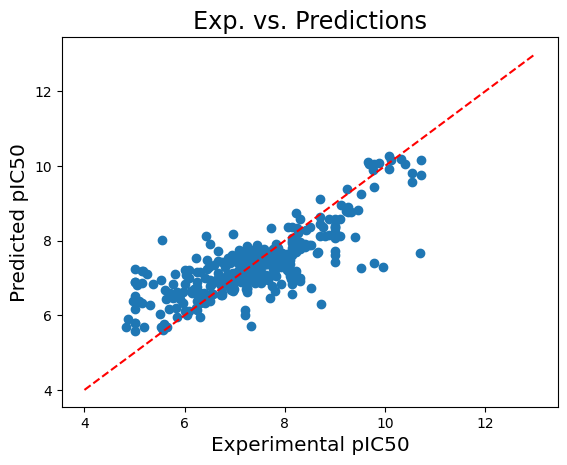

In [ ]:
plt.scatter(test_y, pred_y) # scatter plot 그림.

plt.plot(range(4, 14, 1), range(4, 14, 1),  'r--', ms=0.01,) # diagonal line (대각선)을 그려줌.

plt.xlabel("Experimental pIC50", fontsize='x-large')
plt.ylabel("Predicted pIC50", fontsize='x-large')
plt.title("Exp. vs. Predictions", fontsize='xx-large')

In [ ]:
rf_regressor_desc.feature_importances_

array([8.44646143e-03, 7.15257440e-03, 7.55612583e-03, 9.16292082e-03,
       5.57847399e-03, 1.46184912e-02, 1.76303657e-03, 2.33439677e-03,
       1.82991751e-03, 9.21952068e-04, 0.00000000e+00, 1.55023293e-02,
       6.21802414e-03, 4.61061422e-03, 1.52833971e-02, 6.55444647e-03,
       5.52352395e-03, 1.29518029e-02, 3.84791814e-03, 1.87315386e-02,
       6.27018513e-03, 9.12363255e-03, 1.74486605e-02, 8.62313079e-03,
       2.13707899e-02, 7.78851517e-03, 2.02110031e-02, 6.57186289e-03,
       5.18592168e-03, 5.66271772e-03, 1.72478661e-03, 1.09076361e-03,
       2.42493744e-03, 3.19660779e-03, 3.60585864e-03, 3.22721981e-03,
       1.23939208e-02, 3.53991897e-03, 8.23787941e-03, 4.46261792e-03,
       4.73283875e-03, 6.65704268e-03, 2.21933118e-03, 5.32832749e-03,
       5.31797610e-03, 3.84855318e-03, 3.07437728e-03, 4.91745261e-03,
       5.33843068e-03, 4.52744707e-03, 3.11878465e-03, 8.43654722e-04,
       7.01786209e-04, 1.49483414e-02, 3.15576082e-02, 7.70584320e-03,
      

# Fingerprint와 Descriptor를 동시에 사용해보자.

X_df 와 desc_df 를 합치는 명령

In [ ]:
new_table = pd.concat([X_df, desc_df], axis=1)

In [ ]:
new_table

,bit_0,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,bit_9,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1715,0,1,0,0,1,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
1716,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1717,0,0,0,0,1,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
1718,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


* train_test_split
* model 선언
* model 학습
* 결과 검증

# 다른 하이퍼 파라미터를 가진 모델을 만들어 보자
--------

Tree 개수를 증가시키면 모델의 정확도가 향상될 것인가?

In [ ]:
rf_regressor2 = RandomForestRegressor(n_estimators=500, random_state=123456)

In [ ]:
rf_regressor2.fit(train_X, train_y)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(n_estimators=500, random_state=123456)

In [ ]:
pred_y = rf_regressor2.predict(test_X)
mean_squared_error(test_y, pred_y)

0.543081783897674

Text(0.5, 1.0, 'Exp. vs. Predictions')

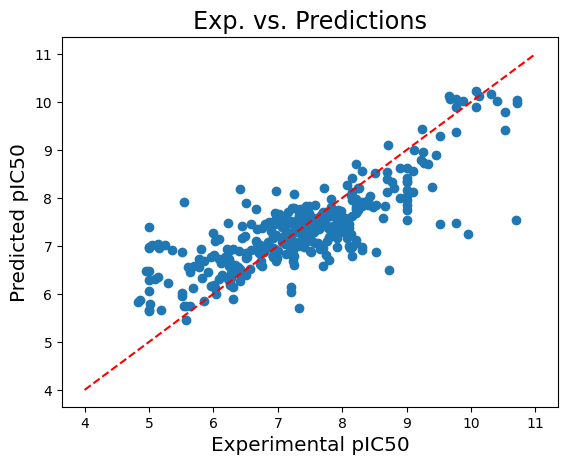

In [ ]:
plt.scatter(test_y, pred_y)

plt.plot(range(4, 12, 1), range(4, 12, 1),  'r--', ms=0.01,) # diagonal line (대각선)을 그려줌.

plt.xlabel("Experimental pIC50", fontsize='x-large')
plt.ylabel("Predicted pIC50", fontsize='x-large')
plt.title("Exp. vs. Predictions", fontsize='xx-large')

# 다른 Tree-based algorithms
-------
* XGBoost: https://xgboost.readthedocs.io/en/stable/get_started.html
* lightGBM: https://lightgbm.readthedocs.io/en/latest/


In [ ]:
import xgboost as xgb
from xgboost import XGBRegressor

In [ ]:
xgb_reg = XGBRegressor()

In [ ]:
xgb_reg.fit(train_X, train_y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
pred_y = xgb_reg.predict(test_X)

In [ ]:
pred_y

array([ 9.479395 , 10.1999   ,  6.537819 ,  6.2119637,  6.5067873,
        7.3373857,  7.040624 ,  6.1895165,  7.758125 ,  7.8872585,
        8.228612 ,  6.5810943,  8.74827  ,  6.2418737,  7.4202757,
        7.4368734,  7.372392 ,  6.18502  ,  7.134637 ,  5.6564956,
        5.834971 ,  7.0681224,  8.015607 ,  7.2507405,  7.104009 ,
        7.1387033,  7.507895 ,  7.518846 ,  7.0717545,  6.4166207,
       10.051367 ,  8.125105 ,  7.513666 ,  6.3869123,  7.862502 ,
        7.477051 ,  7.3444896,  6.1923223,  6.1479053,  6.3215637,
        5.2237625,  6.867542 ,  7.391382 ,  9.996971 ,  6.445169 ,
        7.540836 ,  7.4696317, 10.225382 ,  7.3688745,  8.648147 ,
        7.325069 ,  6.3203974,  6.9049435,  7.629136 ,  6.911374 ,
        6.2388954,  6.3581996,  6.2048125,  7.2678547,  7.082005 ,
        6.985903 ,  7.140985 ,  5.666897 ,  7.39678  ,  7.948505 ,
        7.376518 ,  6.2803483,  5.675162 ,  6.7524757,  7.9421277,
        6.2679663,  8.209809 ,  9.120976 ,  8.312006 ,  8.2378

In [ ]:
mean_squared_error(test_y, pred_y)

0.594478964805603

Text(0.5, 1.0, 'Exp. vs. Predictions')

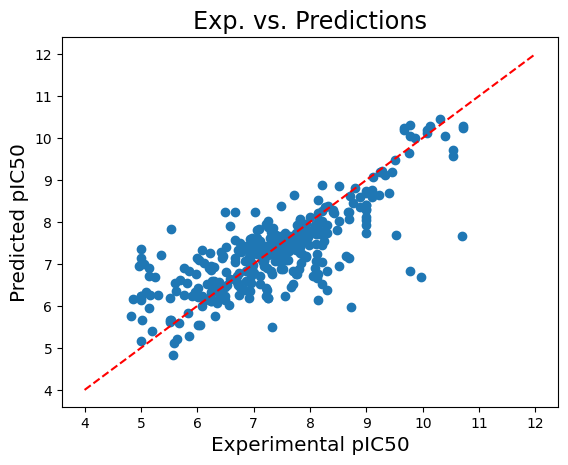

In [ ]:
plt.scatter(test_y, pred_y)
plt.plot(range(4, 13, 1), range(4, 13, 1),  'r--', ms=0.01,) # diagonal line (대각선)을 그려줌.

plt.xlabel("Experimental pIC50", fontsize='x-large')
plt.ylabel("Predicted pIC50", fontsize='x-large')
plt.title("Exp. vs. Predictions", fontsize='xx-large')

추천 참고 도서:

https://product.kyobobook.co.kr/detail/S000211513166

싸이킷런 비공식 한국어 번역 페이지:

https://panda5176.github.io/scikit-learn-korean/

# 숙제:
1. RF와 XGBoost regressor를 사용하여 하이퍼 파라미터를 바꾸면서 실습에서 훈련된 모델 보다 더 정확한 모델을 만들어보기.
n_estimator 및 max_depth 값을 바꾸면서 mse 값과 corrcoef 값이 어떻게 바뀌는지 확인.


2. fingerprint의 bit = (256, 512, 2048)와 radius = (1, 2)를 바꾸어 가면서 더 나은 모델 만들어보기.

3. fingerprint + descriptor 를 동시에 사용하면 어떨까, pd.concat([df1, df2], axis=1)?